# 48 — Best/worst SC RMSD scatter: colour-coding exploration

**Scoped exploration, not a replacement for
[47_afdb_apo_holo_key_plots.ipynb](47_afdb_apo_holo_key_plots.ipynb).** The best-vs-worst SC RMSD
bin scatter in nb47 currently uses a fixed, condition-independent black/red pair (chosen only to
avoid the orange-on-orange clash the Holo condition had with the old TARGET_C/tomato scheme). That
still doesn't read well — black/red isn't tied to the notebook's own colour identity (purple/blue/
orange per condition) the way every other plot is.

This notebook tries same-hue alternatives instead — light/dark shades of each condition's own
colour — and drops the alpha blending nb47 uses to fight overplotting, since after the RMSD-bin
change (`>3` instead of `>5`) and the general pooled-corpus sizes, the point counts here are much
smaller than what the original per-dataset notebooks were plotting (max ~5,400 in the `<1` bin, as
few as ~120–600 in the worst bin) — dense overplotting may no longer be the problem it was.

Two variants per condition, both at full opacity:
- **A — light worst**: `<1` bin in the condition's own colour, `>3` bin in a lighter tint of it
- **B — dark best**: `<1` bin in a darker shade of the condition's colour, `>3` bin in the colour itself

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

PROJ = Path.cwd().parent / 'DATA' / 'drugclip'
FIG_DIR = PROJ / 'RESULTS/scatter_color_exploration/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_C = '#2CA02C'

CONDITIONS = [
    {
        'key': 'afdb', 'name': 'AFDB', 'color': '#9467BD',
        'path': PROJ / 'RESULTS/afdb_pockets_6A/afdb_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_afdb', 'rmsd_col': 'sc_rmsd_local',
    },
    {
        'key': 'apo', 'name': 'Apo', 'color': '#1F77B4',
        'path': PROJ / 'RESULTS/ahoj_pooled/ahoj_apo_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_apo', 'rmsd_col': 'sc_rmsd',
    },
    {
        'key': 'holo', 'name': 'Holo', 'color': '#FF7F0E',
        'path': PROJ / 'RESULTS/ahoj_pooled/ahoj_holo_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_holo', 'rmsd_col': 'sc_rmsd',
    },
]

SCORE_LIM   = (-0.45, 0.95)
SCORE_TICKS = np.arange(-0.4, 0.81, 0.2)
BIN_EDGES   = [0, 1.0, 2.0, 3.0, np.inf]
BIN_LABELS  = ['<1', '1–2', '2–3', '>3']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                      'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12})


def square(fig):
    for ax in fig.axes:
        ax.set_box_aspect(1)
    return fig


def lighten(hex_color, amount=0.55):
    """Blend toward white."""
    c = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(c + (np.array([1, 1, 1]) - c) * amount)


def darken(hex_color, amount=0.45):
    """Blend toward black."""
    c = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(c * (1 - amount))


def save_fig(fig, name, save, dpi):
    if save:
        fig.savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight')

## Load

In [2]:
for c in CONDITIONS:
    df = pd.read_csv(c['path'], sep='\t')
    df['rmsd_bin'] = pd.cut(df[c['rmsd_col']], bins=BIN_EDGES, labels=BIN_LABELS, right=False)
    c['df'] = df
    print(f"{c['name']:<5s}  n={len(df):,}  ({c['path'].name})")

AFDB   n=13,062  (afdb_vs_exp_scores_pooled_dedup.tsv)
Apo    n=5,244  (ahoj_apo_vs_exp_scores_pooled_dedup.tsv)
Holo   n=9,620  (ahoj_holo_vs_exp_scores_pooled_dedup.tsv)


## Plot function

Same scatter as nb47's `plot_best_worst_scatter`, parameterised by the `<1` / `>3` colours and
marker alpha so both variants share one code path.

In [3]:
def plot_variant(c, best_color, worst_color, alpha, variant_label, variant_key, save=True, dpi=600):
    df, name, score_col = c['df'], c['name'], c['score_col']
    print(f'{name} — {variant_label} (n={len(df):,} pooled)')
    fig, ax = plt.subplots(figsize=(6, 6))
    for b, col in [('<1', best_color), ('>3', worst_color)]:
        sub = df[df['rmsd_bin'] == b]
        if len(sub) < 5:
            continue
        r, _ = stats.pearsonr(sub['score_exp'], sub[score_col])
        ax.scatter(sub['score_exp'], sub[score_col], s=5, alpha=alpha, color=col,
                   label=f'SC RMSD {b} Å  Pearson r={r:.2f}  (n={len(sub):,})', rasterized=True)
    ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
    ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
    ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
    ax.set_xlabel('Score (experimental pocket)')
    ax.set_ylabel(f'Score ({name} pocket)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_variant_{variant_key}', save, dpi)
    return fig

## AFDB

AFDB — A — full colour <1 Å, light >3 Å (n=13,062 pooled)


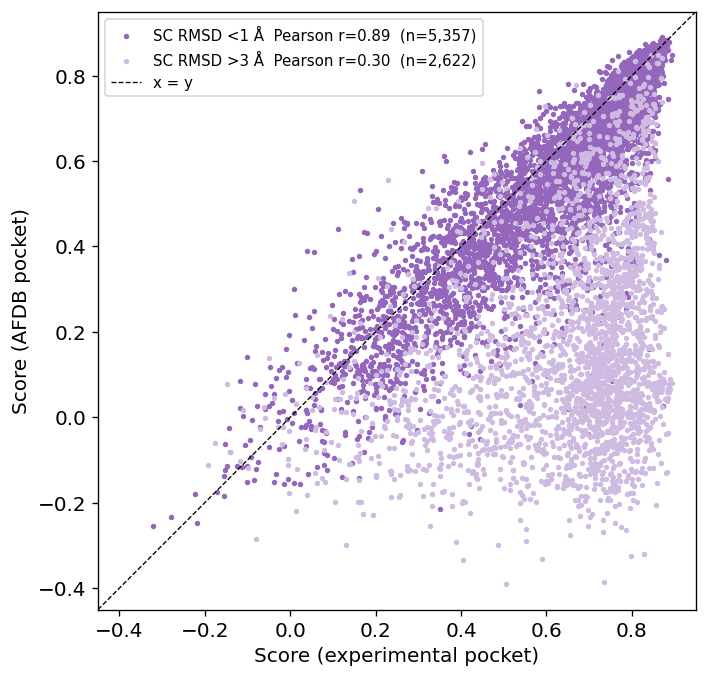

In [4]:
_c = CONDITIONS[0]
plot_variant(_c, _c['color'], lighten(_c['color']), alpha=1.0,
             variant_label='A — full colour <1 Å, light >3 Å', variant_key='A');

AFDB — B — dark <1 Å, full colour >3 Å (n=13,062 pooled)


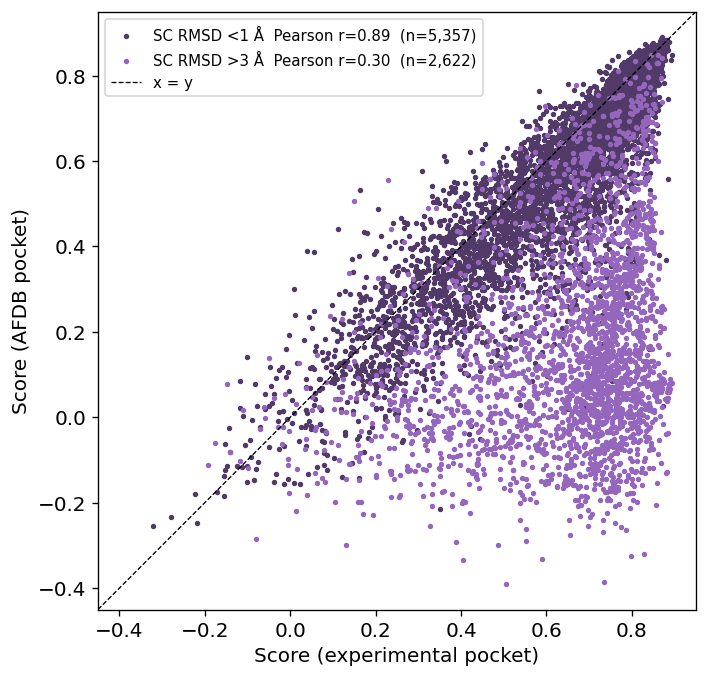

In [5]:
plot_variant(_c, darken(_c['color']), _c['color'], alpha=1.0,
             variant_label='B — dark <1 Å, full colour >3 Å', variant_key='B');

## Apo

Apo — A — full colour <1 Å, light >3 Å (n=5,244 pooled)


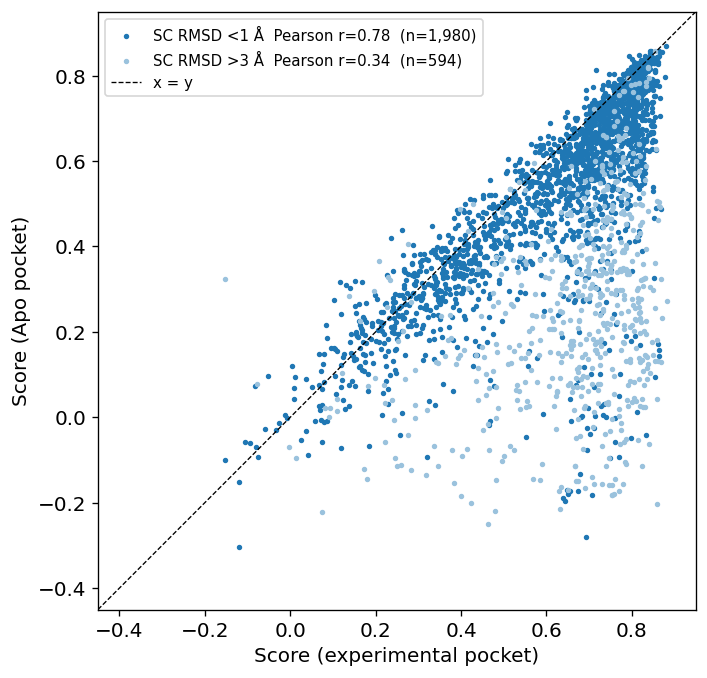

In [6]:
_c = CONDITIONS[1]
plot_variant(_c, _c['color'], lighten(_c['color']), alpha=1.0,
             variant_label='A — full colour <1 Å, light >3 Å', variant_key='A');

Apo — B — dark <1 Å, full colour >3 Å (n=5,244 pooled)


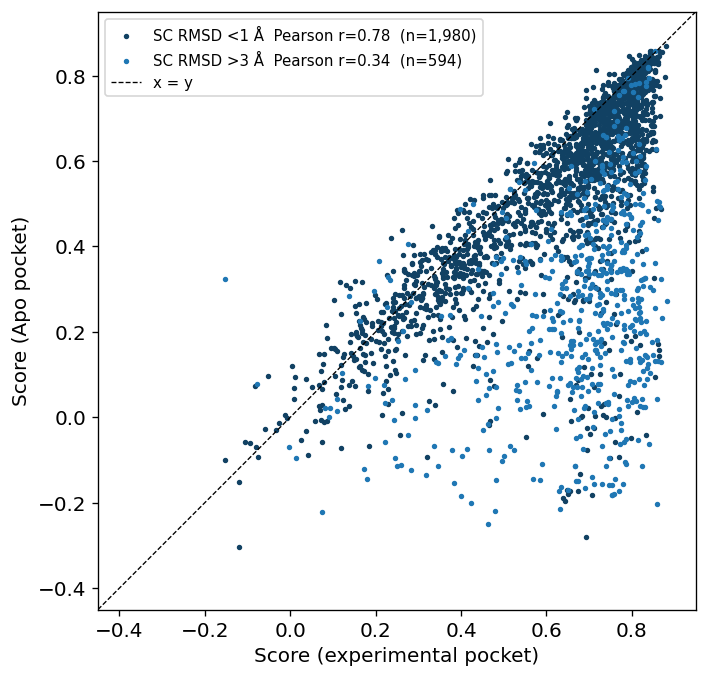

In [7]:
plot_variant(_c, darken(_c['color']), _c['color'], alpha=1.0,
             variant_label='B — dark <1 Å, full colour >3 Å', variant_key='B');

## Holo

Holo — A — full colour <1 Å, light >3 Å (n=9,620 pooled)


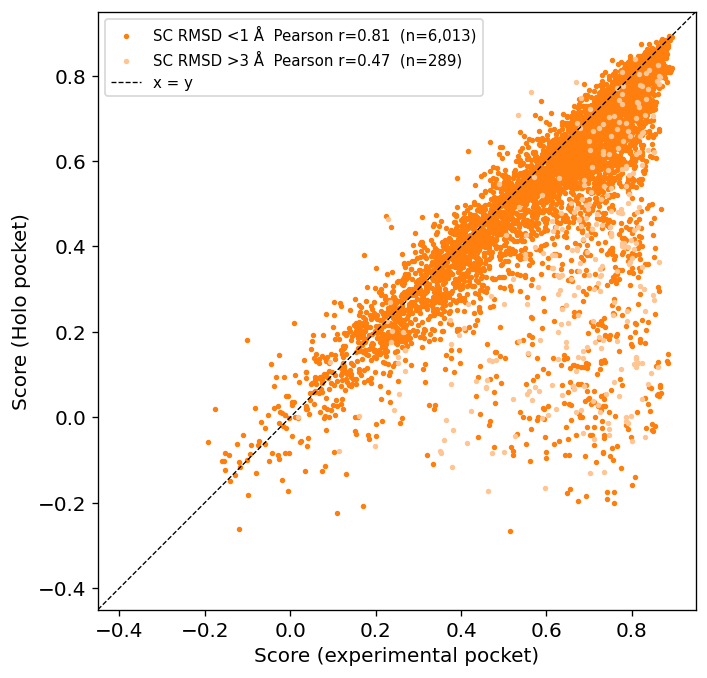

In [8]:
_c = CONDITIONS[2]
plot_variant(_c, _c['color'], lighten(_c['color']), alpha=1.0,
             variant_label='A — full colour <1 Å, light >3 Å', variant_key='A');

Holo — B — dark <1 Å, full colour >3 Å (n=9,620 pooled)


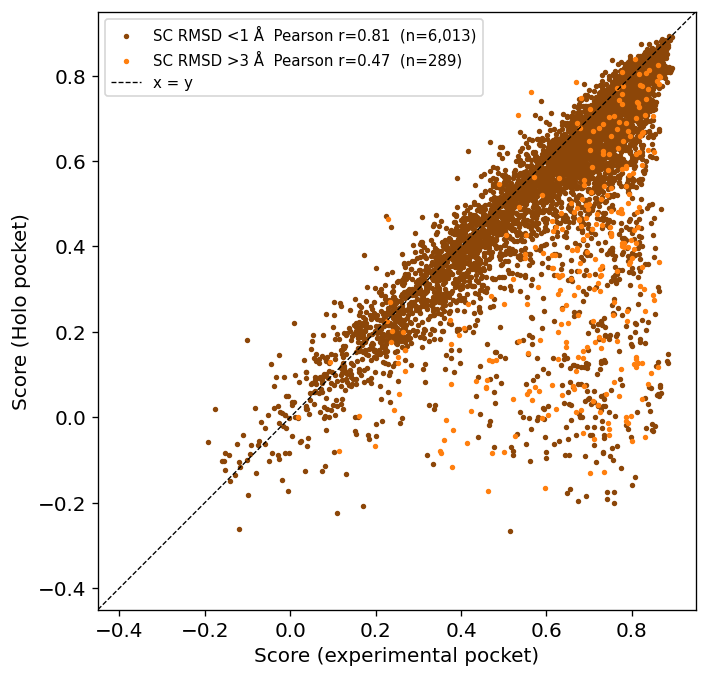

In [9]:
plot_variant(_c, darken(_c['color']), _c['color'], alpha=1.0,
             variant_label='B — dark <1 Å, full colour >3 Å', variant_key='B');

## Marker-shape variants

Colour alone still asks the reader to tell two clusters of near-identical small dots apart. Adding a
second visual channel — marker *shape*, not just shade — is the standard fix (see dataviz guidance:
never rely on colour alone to separate series). Base colours here are Variant B's winner (dark `<1`,
full colour `>3`, from the section above). `<1` stays a small filled circle (it's the dense
background cluster, ~1,980–6,013 points depending on condition); `>3` — the rare, important-to-spot
bin (as few as 289 points for Holo) — gets a distinct marker so it doesn't just have to win on colour.

Tried on AFDB first (densest `<1` cluster, hardest case), then the winning combo across all three.

In [10]:
def plot_marker_variant(c, best_marker, worst_marker, worst_size, variant_label, variant_key, save=True, dpi=600):
    df, name, score_col, color = c['df'], c['name'], c['score_col'], c['color']
    print(f'{name} — {variant_label} (n={len(df):,} pooled)')
    best_color, worst_color = darken(color), color
    fig, ax = plt.subplots(figsize=(6, 6))
    sub_best = df[df['rmsd_bin'] == '<1']
    sub_worst = df[df['rmsd_bin'] == '>3']
    r_best, _  = stats.pearsonr(sub_best['score_exp'], sub_best[score_col])
    r_worst, _ = stats.pearsonr(sub_worst['score_exp'], sub_worst[score_col])
    ax.scatter(sub_best['score_exp'], sub_best[score_col], s=5, alpha=1.0, color=best_color,
               marker=best_marker, label=f'SC RMSD <1 Å  Pearson r={r_best:.2f}  (n={len(sub_best):,})',
               rasterized=True)
    ax.scatter(sub_worst['score_exp'], sub_worst[score_col], s=worst_size, alpha=1.0, color=worst_color,
               marker=worst_marker, edgecolors='black', linewidths=0.2,
               label=f'SC RMSD >3 Å  Pearson r={r_worst:.2f}  (n={len(sub_worst):,})', rasterized=True)
    ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
    ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
    ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
    ax.set_xlabel('Score (experimental pocket)')
    ax.set_ylabel(f'Score ({name} pocket)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_marker_{variant_key}', save, dpi)
    return fig

### AFDB — trying shapes for the `>3` bin

AFDB — circle <1 Å / triangle >3 Å (n=13,062 pooled)


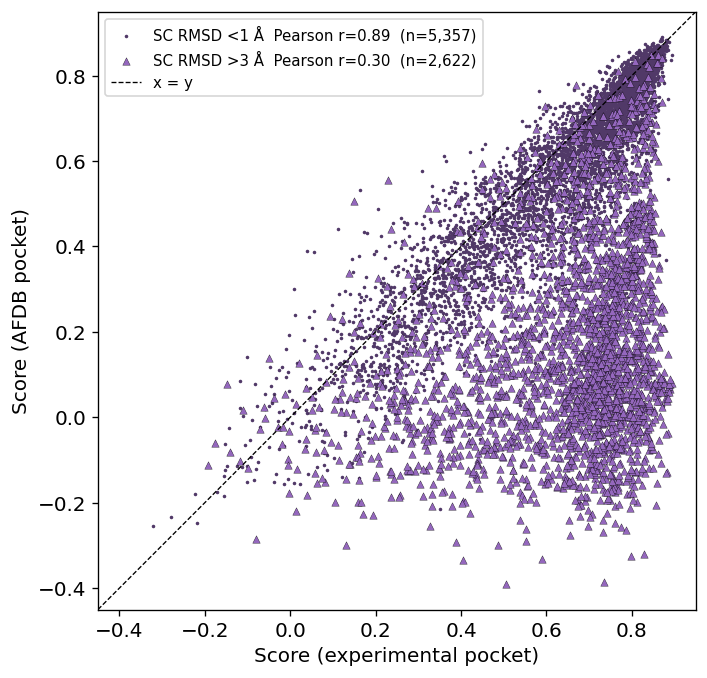

In [11]:
_c = CONDITIONS[0]
plot_marker_variant(_c, '.', '^', 20, 'circle <1 Å / triangle >3 Å', variant_key='triangle');

AFDB — circle <1 Å / x >3 Å (n=13,062 pooled)


/var/folders/7g/mgz14fdd72sb7p9dl4w7m24h0000gn/T/ipykernel_20039/3025642231.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sub_worst['score_exp'], sub_worst[score_col], s=worst_size, alpha=1.0, color=worst_color,


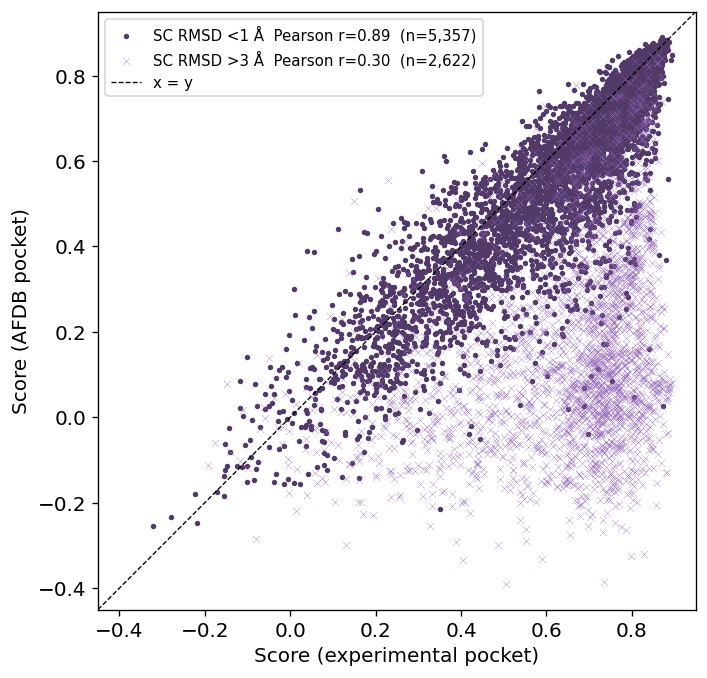

In [12]:
plot_marker_variant(_c, 'o', 'x', 18, 'circle <1 Å / x >3 Å', variant_key='x');

AFDB — circle <1 Å / diamond >3 Å (n=13,062 pooled)


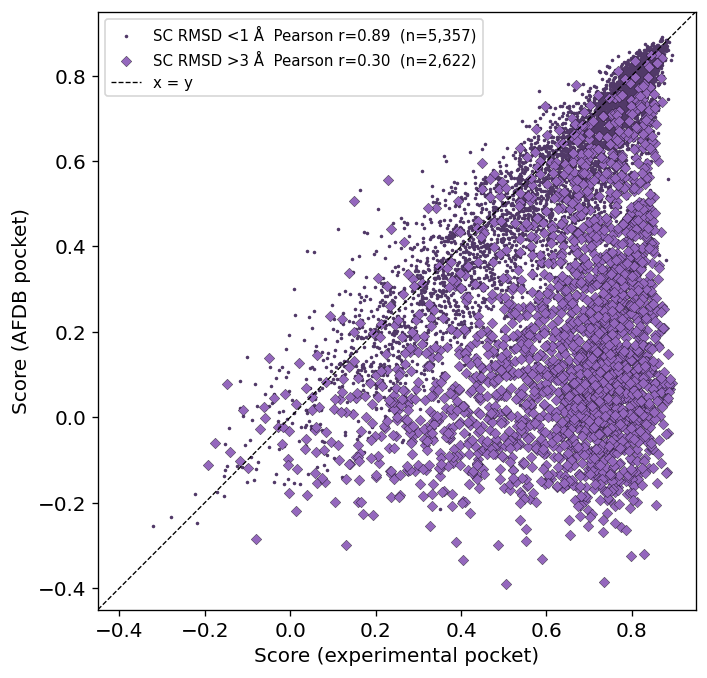

In [13]:
plot_marker_variant(_c, '.', 'D', 20, 'circle <1 Å / diamond >3 Å', variant_key='diamond');

### Winning combo (triangle) across all three conditions

Apo — circle <1 Å / triangle >3 Å (n=5,244 pooled)


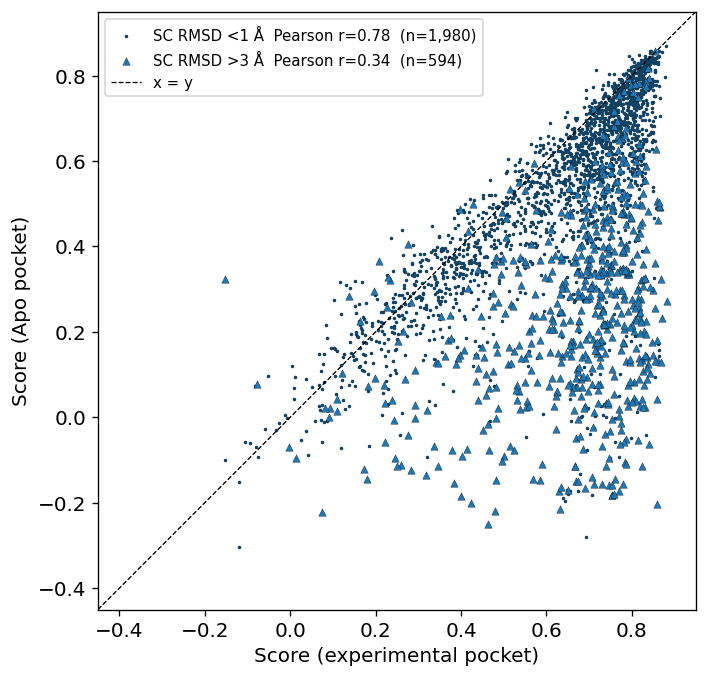

In [14]:
plot_marker_variant(CONDITIONS[1], '.', '^', 20, 'circle <1 Å / triangle >3 Å', variant_key='triangle');

Holo — circle <1 Å / triangle >3 Å (n=9,620 pooled)


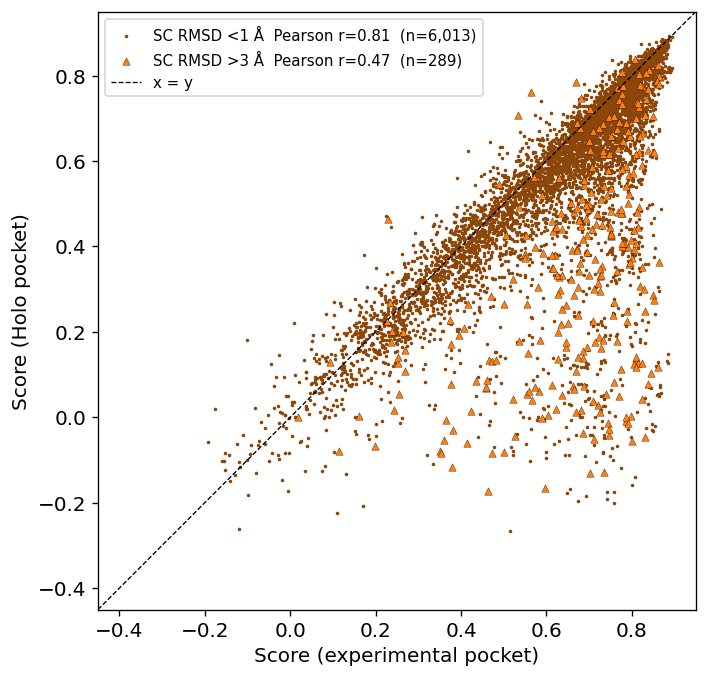

In [15]:
plot_marker_variant(CONDITIONS[2], '.', '^', 20, 'circle <1 Å / triangle >3 Å', variant_key='triangle');